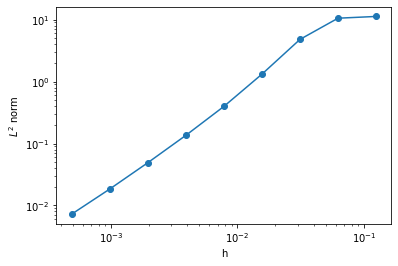

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from p2a import central_diff_neumann


def exact_soln(X,Y):
    gradX_phi = 8*np.pi * X*np.cos(4*np.pi*X**2)*np.cos(-2*np.pi*Y**3)
    gradY_phi = 6*np.pi * Y**2*np.sin(4*np.pi*X**2)*np.sin(-2*np.pi*Y**3)
    return gradX_phi, gradY_phi

def phi_function(X,Y):
    phi = np.sin(4*np.pi*X**2)*np.cos(2*np.pi*Y**3)
    return phi

def L_sq_norm(fXp, fYp, fX, fY, N):
    h = 1/N
    errX_sq = (fXp - fX)**2
    errY_sq = (fYp - fY)**2
    return np.sqrt( h**2 * np.sum(errX_sq + errY_sq) )


Ns = [2**i for i in np.arange(3,12,1)]
hs = [1/n for n in Ns]
err = np.zeros(len(Ns), dtype=float)

for i in range(len(Ns)):
    N = Ns[i]

    x = np.linspace(0,1,N)
    y = np.linspace(0,1,N)
    X,Y = np.meshgrid(x,y, indexing='ij')

    gradX_exact, gradY_exact = exact_soln(X,Y)

    phi = phi_function(X,Y)
    gradX_approx, gradY_approx = central_diff_neumann(X,Y,phi)
    
    err[i] = L_sq_norm(gradX_approx, gradY_approx, gradX_exact, gradY_exact, N)

fig,ax = plt.subplots()
ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.plot(hs, err, '-o')
ax.set_xlabel('h')
ax.set_ylabel(r'$L^2$ norm')

plt.savefig('p2b.png')
plt.show()